# Priority-Aware LRU Cache

Implement a fixed-capacity cache with integer keys, values, and priority levels. Support get(key), put(key, value, priority), and updatePriority(key, newPriority) operations in O(1) time. When full, evict the least recently used entry among those with the lowest priority.

### Example:

Input:

```
capacity = 2
numOperations = 9
operationTypes = ['put', 'put', 'get', 'put', 'get', 'updatePriority', 'put', 'get', 'get']
keys = [1, 2, 1, 3, 2, 3, 4, 3, 4]
values = [10, 20, 0, 30, 0, 0, 40, 0, 0]
priorities = [1, 2, 0, 1, 0, 3, 1, 0, 0]
```

###  Input Format

```
The input is given in five lines:

Two space-separated integers: capacity and numOperations. 1 ≤ capacity ≤ 10^5, 1 ≤ numOperations ≤ 10^6.
numOperations space-separated strings operationTypes[i], each in {"get","put","updatePriority"}.
numOperations space-separated integers keys[i], 0 ≤ keys[i] ≤ 10^9.
numOperations space-separated integers values[i]; for operations other than put, placeholders (e.g., 0) may be used; for put, -10^9 ≤ values[i] ≤ 10^9.
numOperations space-separated integers priorities[i]; for get operations placeholders (e.g., 0) may be used; for put or updatePriority, 0 ≤ priorities[i] ≤ 10^9.
```

### Constraints

```
1 <= capacity <= 10^5
1 <= numOperations <= 10^6
operationTypes.length == numOperations
keys.length == numOperations
values.length == numOperations
priorities.length == numOperations
For all i in [0, numOperations): operationTypes[i] in {"get","put","updatePriority"}
For all i where operationTypes[i] == "get": 0 <= keys[i] <= 10^9
For all i where operationTypes[i] == "put": 0 <= keys[i] <= 10^9, -10^9 <= values[i] <= 10^9, 0 <= priorities[i] <= 10^9
For all i where operationTypes[i] == "updatePriority": 0 <= keys[i] <= 10^9, 0 <= priorities[i] <= 10^9
```

### Output Format

Output an array of integers, one per get operation in the order they occur. For each get, print the value associated with the key if present, or -1 if the key is not in the cache. Each integer should be on its own line.


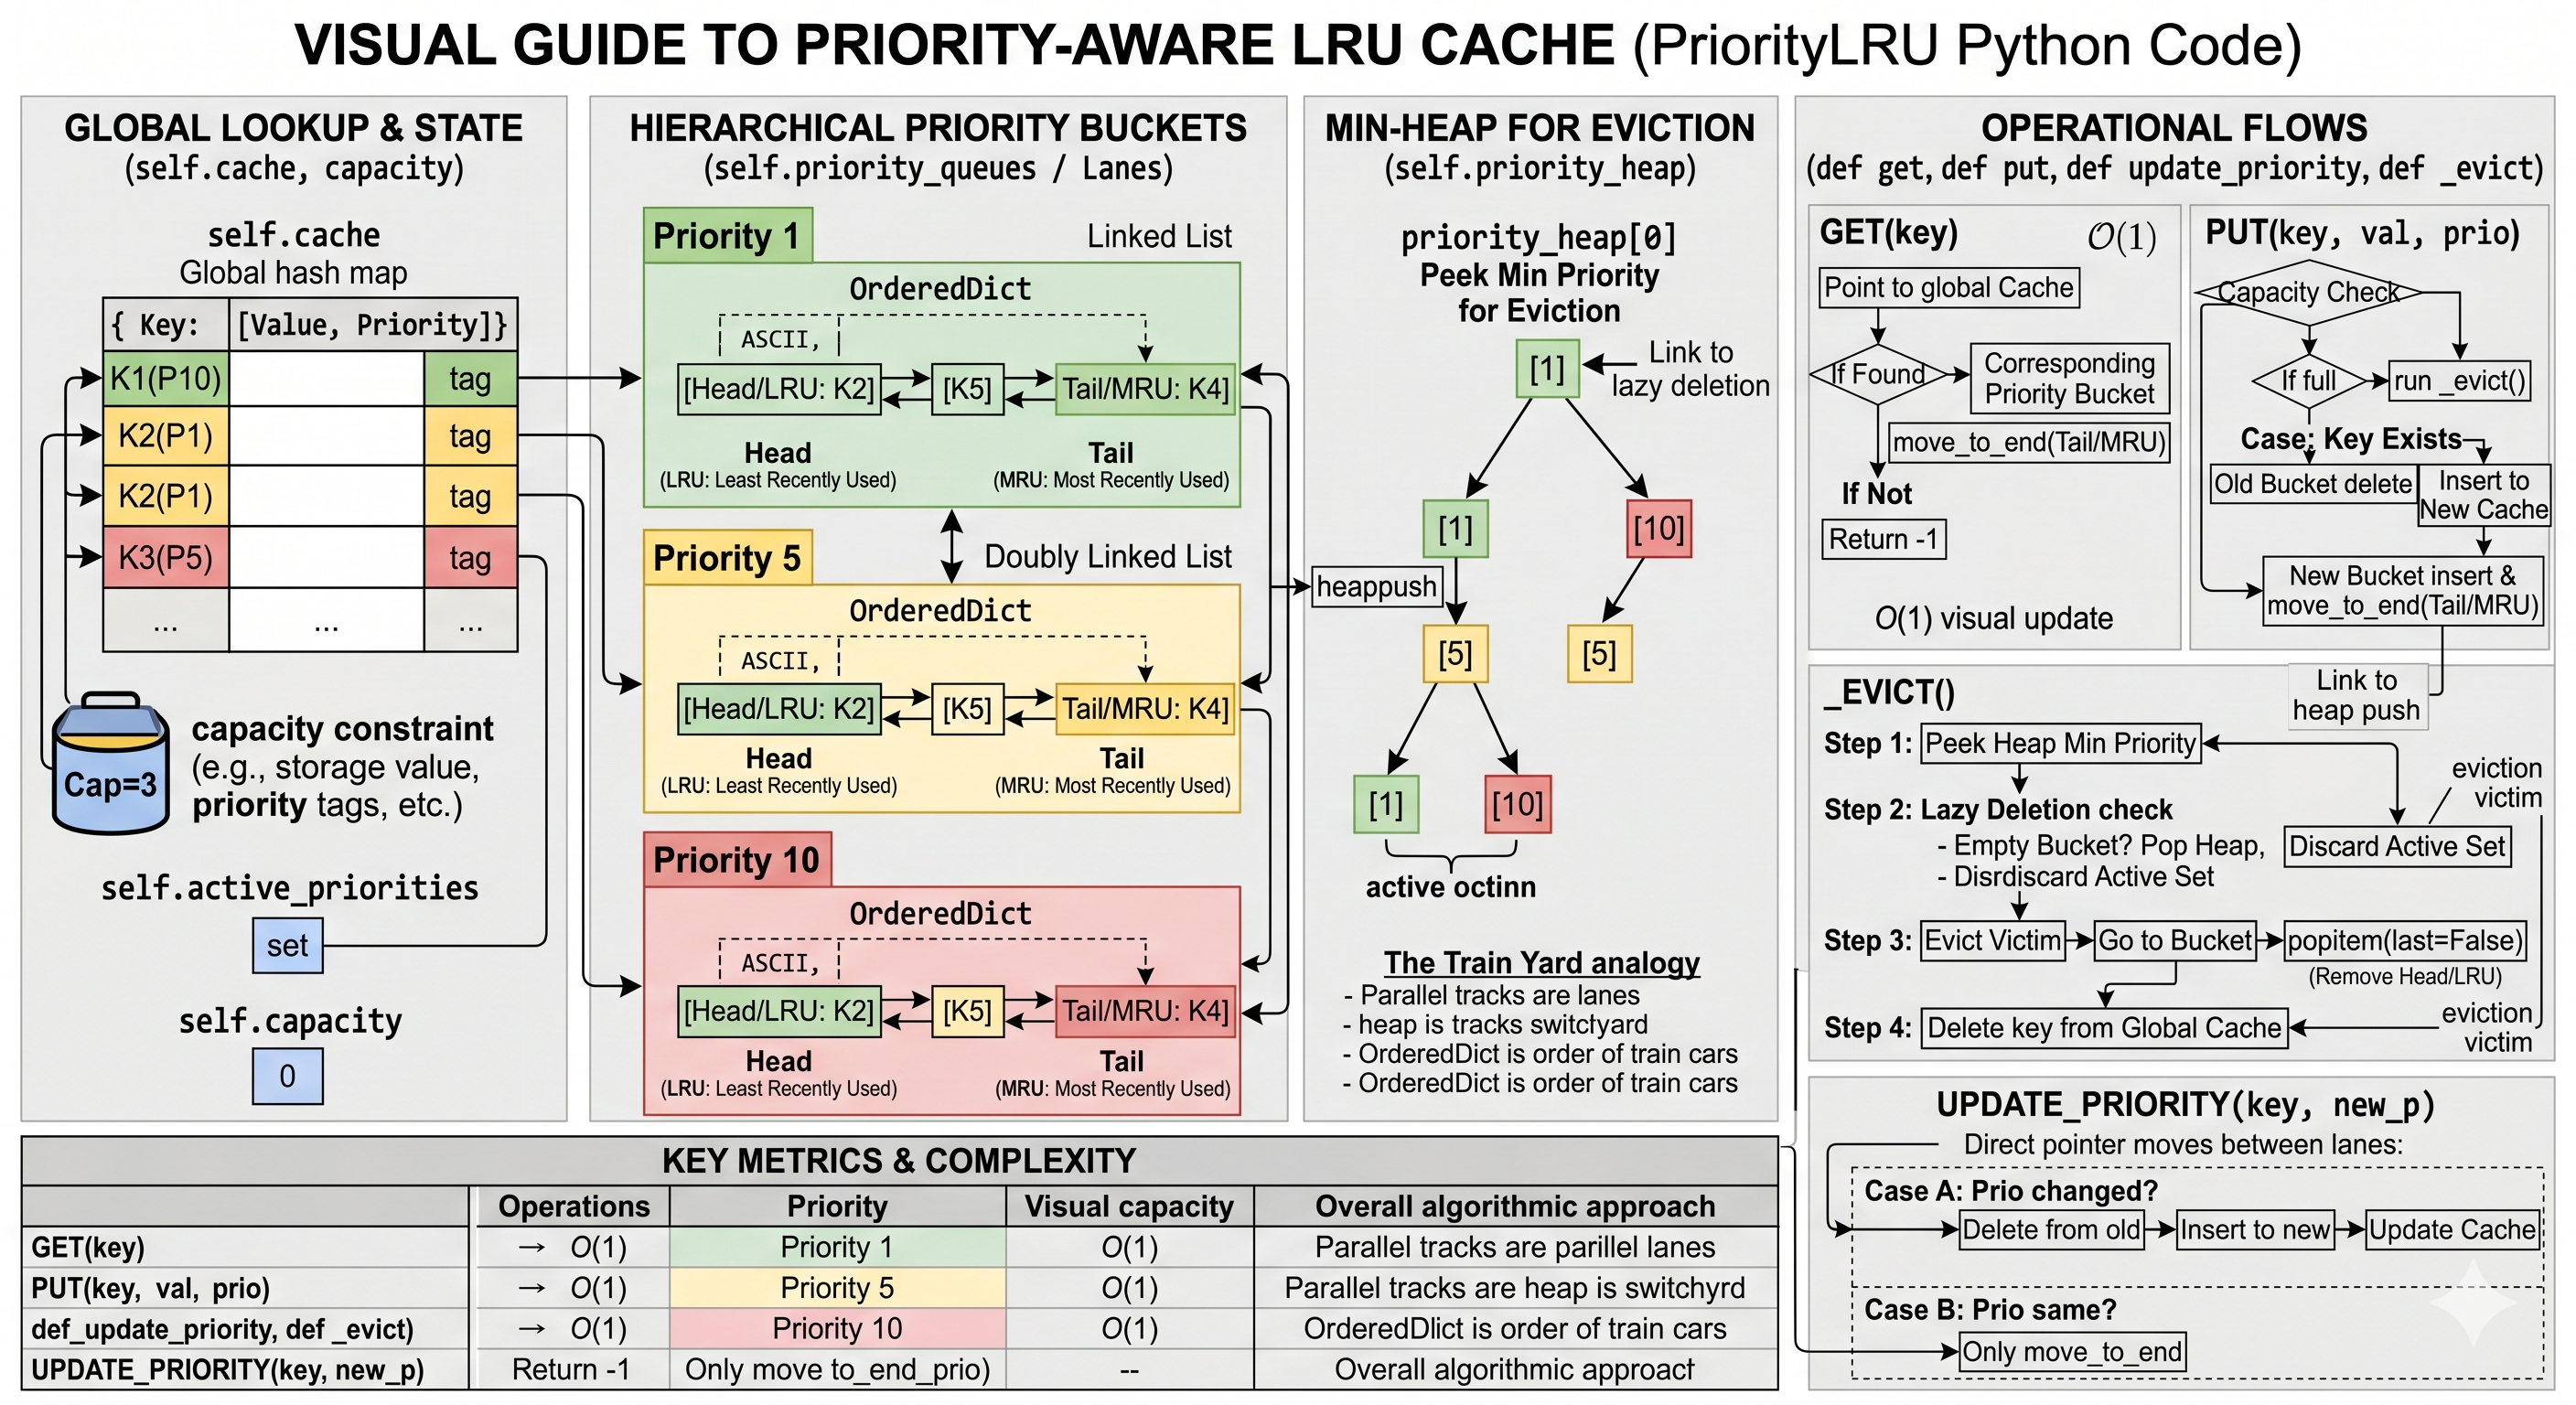

In [ ]:
#!/bin/python3

import math
import os
import random
import re
import sys

#
# Complete the 'simulatePriorityCache' function below.
#
# The function is expected to return an INTEGER_ARRAY.
# The function accepts following parameters:
#  1. INTEGER capacity
#  2. INTEGER numOperations
#  3. STRING_ARRAY operationTypes
#  4. INTEGER_ARRAY keys
#  5. INTEGER_ARRAY values
#  6. INTEGER_ARRAY priorities
#

import heapq
from collections import OrderedDict

class PriorityLRU:
    def __init__(self, capacity: int):
        self.capacity = capacity
        self.cache = {} 
        self.priority_queues = {} 
        self.priority_heap = []
        self.active_priorities = set()


    def _ensure_priority_in_heap(self, priority: int):
        if priority not in self.active_priorities:
            heapq.heappush(self.priority_heap, priority) 
            self.active_priorities.add(priority)

    def _add_to_priority_queues(self, key: int, priority: int):
        if priority not in self.priority_queues:
            self.priority_queues[priority] = OrderedDict()
        self.priority_queues[priority][key] = None
        self.priority_queues[priority].move_to_end(key) 
        self._ensure_priority_in_heap(priority)

    def _evict(self):
        while self.priority_heap:
            min_p = self.priority_heap[0] 
            if min_p not in self.priority_queues or not self.priority_queues[min_p]:
                heapq.heappop(self.priority_heap)
                self.active_priorities.discard(min_p)
                continue
            evicted_key, _ = self.priority_queues[min_p].popitem(last=False) 
            del self.cache[evicted_key]
            return 

    def get(self, key: int) -> int:
        if key not in self.cache:
            return -1
        val, prio = self.cache[key]
        self.priority_queues[prio].move_to_end(key) 
        return val

    def put(self, key: int, value: int, priority: int):
        if self.capacity <= 0:
            return

        if key in self.cache:
            
            _, old_p = self.cache[key]
            del self.priority_queues[old_p][key]
        elif len(self.cache) >= self.capacity:
            self._evict()

        self.cache[key] = [value, priority]
        self._add_to_priority_queues(key, priority)

    def update_priority(self, key: int, new_p: int):
        if key not in self.cache:
            return
        
        val, old_p = self.cache[key]
        if old_p != new_p:
            del self.priority_queues[old_p][key] 
            self.cache[key] = [val, new_p]
            self._add_to_priority_queues(key, new_p) 
        else:
            self.priority_queues[new_p].move_to_end(key) 

def simulatePriorityCache(capacity, numOps, opTypes, keys, values, priorities):
    priority_lru_cache = PriorityLRU(capacity)
    results = []

    for i in range(numOps):
        operation = opTypes[i]
        k, v, p = keys[i], values[i], priorities[i]

        if operation == 'get':
            results.append(priority_lru_cache.get(k))
        elif operation == 'put':
            priority_lru_cache.put(k, v, p)
        elif operation == 'updatePriority':
            priority_lru_cache.update_priority(k, p)
        else:
            raise ValueError("Invalid Operation (get,put,updatePriority)")
            
    return results
    
 

if __name__ == '__main__':
    capacity = int(input().strip())

    numOperations = int(input().strip())

    operationTypes_count = int(input().strip())

    operationTypes = []

    for _ in range(operationTypes_count):
        operationTypes_item = input()
        operationTypes.append(operationTypes_item)

    keys_count = int(input().strip())

    keys = []

    for _ in range(keys_count):
        keys_item = int(input().strip())
        keys.append(keys_item)

    values_count = int(input().strip())

    values = []

    for _ in range(values_count):
        values_item = int(input().strip())
        values.append(values_item)

    priorities_count = int(input().strip())

    priorities = []

    for _ in range(priorities_count):
        priorities_item = int(input().strip())
        priorities.append(priorities_item)

    result = simulatePriorityCache(capacity, numOperations, operationTypes, keys, values, priorities)

    print('\n'.join(map(str, result)))

def simulatePriorityCache(capacity, numOps, opTypes, keys, values, priorities):
    priority_lru_cache = PriorityLRU(capacity)
    results = []

    for i in range(numOps):
        operation = opTypes[i]
        k, v, p = keys[i], values[i], priorities[i]

        if operation == 'get':
            results.append(priority_lru_cache.get(k))
        elif operation == 'put':
            priority_lru_cache.put(k, v, p)
        elif operation == 'updatePriority':
            priority_lru_cache.update_priority(k, p)
        else:
            raise ValueError("Invalid Operation (get,put,updatePriority)")
            
    return results
    
 

if __name__ == '__main__':
    capacity = int(input().strip())

    numOperations = int(input().strip())

    operationTypes_count = int(input().strip())

    operationTypes = []

    for _ in range(operationTypes_count):
        operationTypes_item = input()
        operationTypes.append(operationTypes_item)

    keys_count = int(input().strip())

    keys = []

    for _ in range(keys_count):
        keys_item = int(input().strip())
        keys.append(keys_item)

    values_count = int(input().strip())

    values = []

    for _ in range(values_count):
        values_item = int(input().strip())
        values.append(values_item)

    priorities_count = int(input().strip())

    priorities = []

    for _ in range(priorities_count):
        priorities_item = int(input().strip())
        priorities.append(priorities_item)

    result = simulatePriorityCache(capacity, numOperations, operationTypes, keys, values, priorities)

    print('\n'.join(map(str, result)))